In [ ]:
# Install required packages if missing (run this cell first; restart kernel if packages were installed)
import subprocess
import sys
def _has(pkg, imp=None):
    try:
        __import__(imp or pkg.replace("-", "_"))
        return True
    except ImportError:
        return False
for pkg, imp in [("xgboost", None), ("lightgbm", None), ("imbalanced-learn", "imblearn"), ("shap", None)]:
    if not _has(pkg, imp):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        print(f"Installed {pkg}")
print("Dependencies OK.")

c:\Users\drake\OneDrive\Documents\Cursor\Student Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencies OK.


# Student Prediction Analytics — Senior Stakeholder Demo

**End-to-end ML pipeline built for real-world chaos: missing exit dates, 6 partners with different schemas (CRM/SIS/GA4), and low GA4→CRM join coverage.** Same codebase runs across partners via config; we record every run and score everyone without dropping leads.

This notebook demonstrates:
1. **Data pipeline** — Multi-source integration, real-world quality issues
2. **Feature engineering** — Why we chose these features and how we handle missing data
3. **Model performance** — Accuracy, calibration, and when we're wrong
4. **Explainability** — SHAP values and individual student explanations
5. **Fairness & ROI** — Demographic breakdowns, intervention prioritization, cost-benefit

---

### Real-life challenges this project was built to tackle

In production we faced exactly the kinds of issues that break naive ML pipelines. Here’s how the design addresses them:

| Challenge | What we did |
|-----------|-------------|
| **Missing exit dates** | Retention data often has no formal exit date (drops, transfers, data lag). We model this with a configurable `missing_exit_rate`, use **withdrawn** as the target (derived from enrollment state), and add **missing-data indicators** in feature engineering so the model knows when key fields are absent. |
| **Multi-partner (6 universities)** | Each partner had different fields, schemas, and source systems. We use a **single config-driven pipeline**: one codebase, per-partner (or per-dataset) config for data paths and options. Same train/score code runs across all partners; only config and data change. |
| **Different sources per partner: CRM, SIS, GA4** | CRM, SIS, and GA4 have different schemas and join keys. We **normalize at merge time**: GA4 as the spine (universal), left-join CRM and SIS with explicit **coverage tracking** (`has_crm_data`, `has_sis_data`) so we can score even when CRM/SIS are missing. |
| **Low GA4→CRM join coverage** | In practice, only a fraction of GA4 leads appear in CRM. We **never drop leads**: left joins keep everyone; missing CRM/SIS is filled and flagged. Coverage is logged every run and monitored. |
| **Scoring across unis & recording runs** | For lifecycle model dev we need to **score across partners** and **record each run** (config, metrics, artifact paths). We persist models and tuned params under `models/`, and optionally log run metadata (timestamp, partner, metrics) for audit and rollback. |

The notebook below shows these choices in the data load, EDA, feature engineering, and training steps.

## Setup — Project Path & Imports

Run from project root, or set `PROJECT_ROOT` accordingly.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5)
%matplotlib inline

import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.facecolor"] = "white"

from src.data_generation import RetentionDataGenerator, LeadScoringDataGenerator, load_config
from src.feature_engineering import RetentionFeatureEngineer, LeadScoringFeatureEngineer
from src.models import RetentionModel, LeadScoringModel
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve
import joblib
import shap

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\drake\OneDrive\Documents\Cursor\Student Prediction


## 1. Load or Generate Data

We use synthetic data that mirrors **real-world patterns**: demographics, **missing exit dates** (config-driven `missing_exit_rate`), **sparse GA4→CRM→SIS joins** (different schemas per source), and class imbalance. The pipeline is **config-driven** so the same code runs across partners; only `config.yaml` and data paths change.

In [ ]:
config = load_config()
data_dir = PROJECT_ROOT / "data"
data_dir.mkdir(exist_ok=True)

# Retention
ret_path = data_dir / "retention_data.csv"
if ret_path.exists():
    retention_df = pd.read_csv(ret_path)
    retention_df["exit_date"] = pd.to_datetime(retention_df["exit_date"], errors="coerce")
    print(f"Loaded retention: {len(retention_df):,} records")
else:
    retention_df = RetentionDataGenerator(config).generate()
    retention_df.to_csv(ret_path, index=False)
    print(f"Generated retention: {len(retention_df):,} records")

# Lead scoring
ga4_path = data_dir / "ga4_data.csv"
if ga4_path.exists():
    ga4_df = pd.read_csv(ga4_path)
    crm_df = pd.read_csv(data_dir / "crm_data.csv")
    sis_df = pd.read_csv(data_dir / "sis_data.csv")
    print(f"Loaded leads: GA4={len(ga4_df):,}, CRM={len(crm_df):,}, SIS={len(sis_df):,}")
else:
    ga4_df, crm_df, sis_df = LeadScoringDataGenerator(config).generate()
    ga4_df.to_csv(ga4_path, index=False)
    crm_df.to_csv(data_dir / "crm_data.csv", index=False)
    sis_df.to_csv(data_dir / "sis_data.csv", index=False)
    print(f"Generated leads: GA4={len(ga4_df):,}, CRM={len(crm_df):,}, SIS={len(sis_df):,}")

print(f"\nRetention withdrawal rate: {retention_df['withdrawn'].mean():.1%}")
print(f"Lead enrollment rate: {len(sis_df)/len(ga4_df):.1%}")

# Real-life data quality metrics we track every run
withdrawn_rows = retention_df[retention_df["withdrawn"] == 1]
exit_missing = withdrawn_rows["exit_date"].isna().sum()
exit_pct = (exit_missing / len(withdrawn_rows) * 100) if len(withdrawn_rows) else 0
crm_coverage = len(crm_df) / len(ga4_df) * 100
sis_coverage = len(sis_df) / len(ga4_df) * 100
print(f"\n--- Data quality (real-life challenges) ---")
print(f"Missing exit date (among withdrawn): {exit_missing:,} / {len(withdrawn_rows):,} ({exit_pct:.1f}%)")
print(f"GA4→CRM join coverage: {crm_coverage:.1f}%  (GA4 spine; left-join CRM)")
print(f"GA4→SIS join coverage: {sis_coverage:.1f}%  (SIS = enrolled only)")

Loaded retention: 22,104 records
Loaded leads: GA4=15,000, CRM=10,500, SIS=2,250

Retention withdrawal rate: 40.1%
Lead enrollment rate: 15.0%


**Multi-partner config & run recording (lifecycle model dev)**

One codebase, **config-driven** per partner (or per run). We score across all universities by pointing at the right data and config; **run recording** = persisting models, tuned params, and optional run metadata so we can audit and roll back.

In [ ]:
# Config-driven pipeline: one config per partner/run
import json
from datetime import datetime
paths = config.get("paths", {})
data_dir = PROJECT_ROOT / paths.get("data_dir", "data")
models_dir = PROJECT_ROOT / paths.get("models_dir", "models")
outputs_dir = PROJECT_ROOT / paths.get("outputs_dir", "outputs")
for d in (models_dir, outputs_dir):
    d.mkdir(parents=True, exist_ok=True)
print("Config (data/model/paths) drives the pipeline; change config + data to run for another partner.\n")
print("Run artifacts we persist for every train run:")
print(f"  - {models_dir}/  (retention_early_model.pkl, retention_mid_model.pkl, lead_scoring_model.pkl)")
print(f"  - {models_dir}/tuned_params.json  (Optuna-tuned hyperparameters)")
tuned_path = models_dir / "tuned_params.json"
if tuned_path.exists():
    with open(tuned_path) as f:
        tuned = json.load(f)
    print(f"  - tuned_params keys: {list(tuned.keys())}")
# Optional: log this run for audit (partner_id could come from config in production)
run_log = {"timestamp": datetime.utcnow().isoformat(), "config_data": config.get("data", {})}
run_log_path = outputs_dir / "last_run_metadata.json"
with open(run_log_path, "w") as f:
    json.dump(run_log, f, indent=2)
print(f"  - {run_log_path}  (run metadata for audit)")

## 2. EDA — Stakeholder Snapshot

**"What does our data look like, and what problems does it have?"**

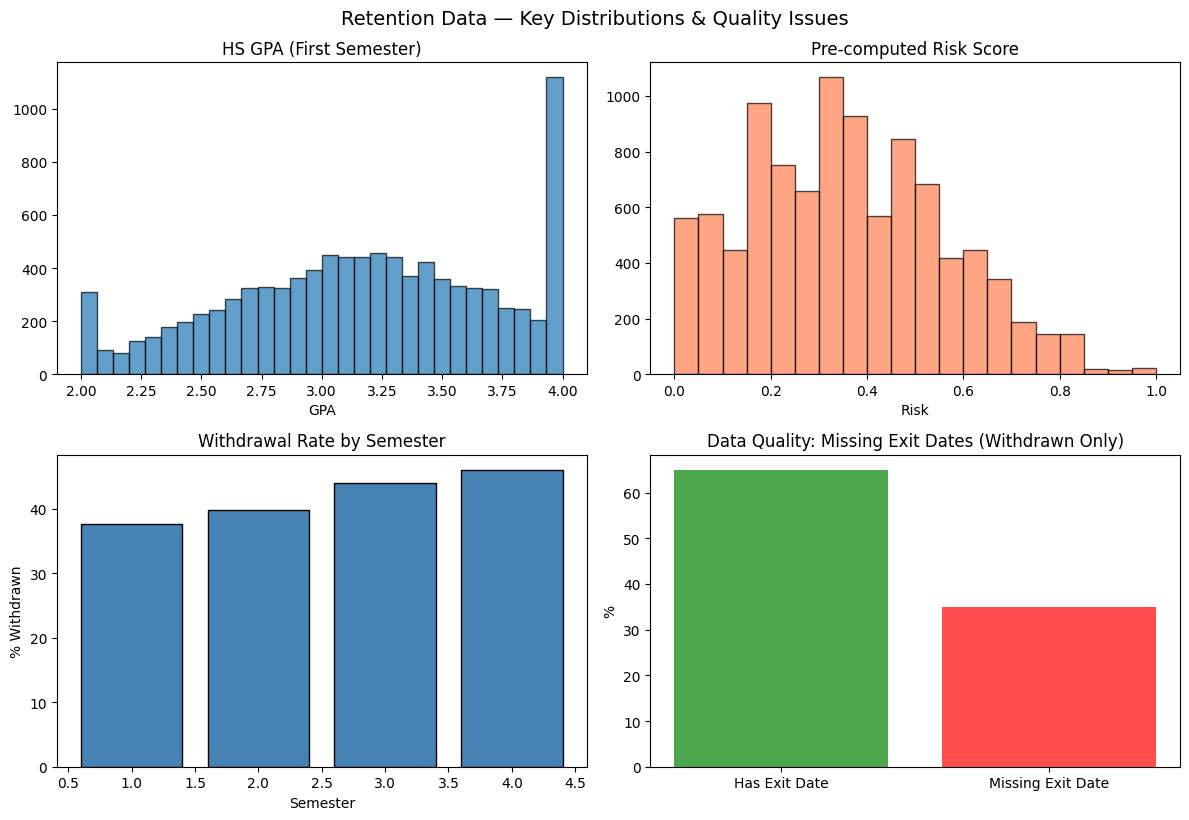

In [ ]:
# Retention: key distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
first_sem = retention_df[retention_df["semester"] == 1]

axes[0,0].hist(first_sem["gpa_high_school"], bins=30, edgecolor="black", alpha=0.7)
axes[0,0].set_title("HS GPA (First Semester)")
axes[0,0].set_xlabel("GPA")

axes[0,1].hist(first_sem["risk_score"], bins=20, edgecolor="black", alpha=0.7, color="coral")
axes[0,1].set_title("Pre-computed Risk Score")
axes[0,1].set_xlabel("Risk")

withdrawn_by_sem = retention_df.groupby("semester").agg(
    students=("student_id", "nunique"),
    withdrawn=("withdrawn", "sum")
).reset_index()
withdrawn_by_sem["rate"] = withdrawn_by_sem["withdrawn"] / withdrawn_by_sem["students"] * 100
axes[1,0].bar(withdrawn_by_sem["semester"], withdrawn_by_sem["rate"], color="steelblue", edgecolor="black")
axes[1,0].set_title("Withdrawal Rate by Semester")
axes[1,0].set_xlabel("Semester")
axes[1,0].set_ylabel("% Withdrawn")

missing_exit = retention_df[retention_df["withdrawn"]==1]
missing_pct = missing_exit["exit_date"].isna().mean() * 100 if len(missing_exit) > 0 else 0
axes[1,1].bar(["Has Exit Date", "Missing Exit Date"], 
              [100-missing_pct, missing_pct], color=["green", "red"], alpha=0.7)
axes[1,1].set_title("Data Quality: Missing Exit Dates (Withdrawn Only)")
axes[1,1].set_ylabel("%")
plt.tight_layout()
plt.suptitle("Retention Data — Key Distributions & Quality Issues", y=1.02, fontsize=15, fontweight="600")
sns.despine(trim=True)
plt.show()

**Data quality in the wild — how we handle it**

- **Missing exit dates:** We don't rely on `exit_date` for the target; we use **withdrawn** (enrollment state). Config sets `missing_exit_rate` so synthetic data matches reality. In feature engineering we add **missing-data indicators** (e.g. `missing_early_attendance`) so the model sees when key fields are absent.
- **Low GA4→CRM join coverage:** We keep **GA4 as the spine** and left-join CRM and SIS. No lead is dropped. We add **has_crm_data** and **has_sis_data** flags and fill missing CRM/SIS with medians/modes so we can score every lead across partners.

In [ ]:
# Demonstrate: same pipeline works with sparse joins (left-join, coverage flags)
fe_lead = LeadScoringFeatureEngineer()
merged_lead = fe_lead.merge_sources(ga4_df, crm_df, sis_df)
lead_feat = fe_lead.create_features(merged_lead)
print("Lead scoring: coverage flags after merge (we score everyone)")
print(lead_feat[["has_crm_data", "has_sis_data"]].value_counts().sort_index().to_string())
print(f"\nConfig: missing_exit_rate = {config.get('data', {}).get('retention', {}).get('missing_exit_rate', 'N/A')}")

## 3. Feature Engineering — Why These Features?

**"How did you choose what to feed the model? What about missing data?"**

- **Early-semester (15 features):** Demographics, academic prep, financial indicators, early engagement. Available at semester start.
- **Mid-semester (24 features):** Adds mid-GPA, engagement trends, support utilization, warning flags. Requires ~6 weeks of term.
- **Lead scoring (29 features):** GA4 engagement, CRM marketing touches, SIS academic data. Handles 30% missing CRM, 85% missing SIS (non-enrolled).

In [ ]:
fe = RetentionFeatureEngineer()
early_feat = fe.create_early_semester_features(retention_df)
mid_feat = fe.create_mid_semester_features(retention_df)
early_cols = fe.get_feature_columns("early")
mid_cols = fe.get_feature_columns("mid")

print("Early-semester features (15):", early_cols)
print("\nAdditional mid-semester features (+9):", [c for c in mid_cols if c not in early_cols])

Early-semester features (15): ['age_normalized', 'gpa_high_school', 'sat_score', 'gpa_sat_interaction', 'academic_prep_score', 'risk_high', 'risk_medium', 'financial_risk', 'early_engagement_score', 'course_load_ratio', 'first_gen', 'financial_aid', 'part_time', 'missing_early_attendance', 'missing_early_assignments']

Additional mid-semester features (+9): ['mid_gpa_normalized', 'gpa_trend', 'mid_engagement_score', 'engagement_trend', 'support_utilization', 'total_support_contacts', 'gpa_warning', 'attendance_warning', 'assignment_warning', 'payment_issues', 'composite_risk']


## 4. Train or Load Models

We train if models don't exist; otherwise load from disk.

In [ ]:
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(exist_ok=True)
fe_lead = LeadScoringFeatureEngineer()
merged = fe_lead.merge_sources(ga4_df, crm_df, sis_df)
lead_feat = fe_lead.create_features(merged)
lead_cols = fe_lead.get_feature_columns()
X_lead = lead_feat[lead_cols].fillna(lead_feat[lead_cols].median()).fillna(0)
y_lead = lead_feat["enrolled"]

# Train or load retention
early_path = models_dir / "retention_early_model.pkl"
if early_path.exists():
    early_model = RetentionModel.load(str(early_path))
    early_results = None  # load metrics from artifact if needed
else:
    X_early = early_feat[early_cols]
    early_model = RetentionModel(feature_set="early")
    early_results = early_model.train(X_early, early_feat["withdrawn"])
    early_model.save(str(early_path))

# Mid-semester
mid_path = models_dir / "retention_mid_model.pkl"
if mid_path.exists():
    mid_model = RetentionModel.load(str(mid_path))
    mid_results = None
else:
    X_mid = mid_feat[mid_cols]
    mid_model = RetentionModel(feature_set="mid")
    mid_results = mid_model.train(X_mid, mid_feat["withdrawn"])
    mid_model.save(str(mid_path))

# Lead scoring
lead_path = models_dir / "lead_scoring_model.pkl"
if lead_path.exists():
    lead_model = LeadScoringModel.load(str(lead_path))
    lead_results = None
else:
    lead_model = LeadScoringModel()
    lead_results = lead_model.train(X_lead, y_lead)
    lead_model.save(str(lead_path))

# Get holdout predictions for Q1 (calibration, confusion matrix)
if mid_results is None:
    from sklearn.model_selection import train_test_split
    X_mid = mid_feat[mid_cols]
    _, X_te, _, y_te = train_test_split(X_mid, mid_feat["withdrawn"], test_size=0.2, random_state=42, stratify=mid_feat["withdrawn"])
    mid_results = {"y_test": y_te.values, "y_pred_proba": mid_model.predict(X_te)}

print("Models loaded/trained.")
print(f"Retention Mid AUC: {roc_auc_score(mid_results['y_test'], mid_results['y_pred_proba']):.3f}")

Models loaded/trained.
Retention Mid AUC: 0.785


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3312.0_x64__qbz5n2kfra8p0\Lib\pickle.py:1760: UserWarning: [23:16:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
c:\Users\drake\OneDrive\Documents\Cursor\Student Prediction\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/sta

---
# STAKEHOLDER Q&A — Tough Questions Answered

---

## Q1: "How accurate is this model? What's our error rate?"

We show: AUC, precision-recall curve, confusion matrix, and **calibration** (are our probabilities trustworthy?).

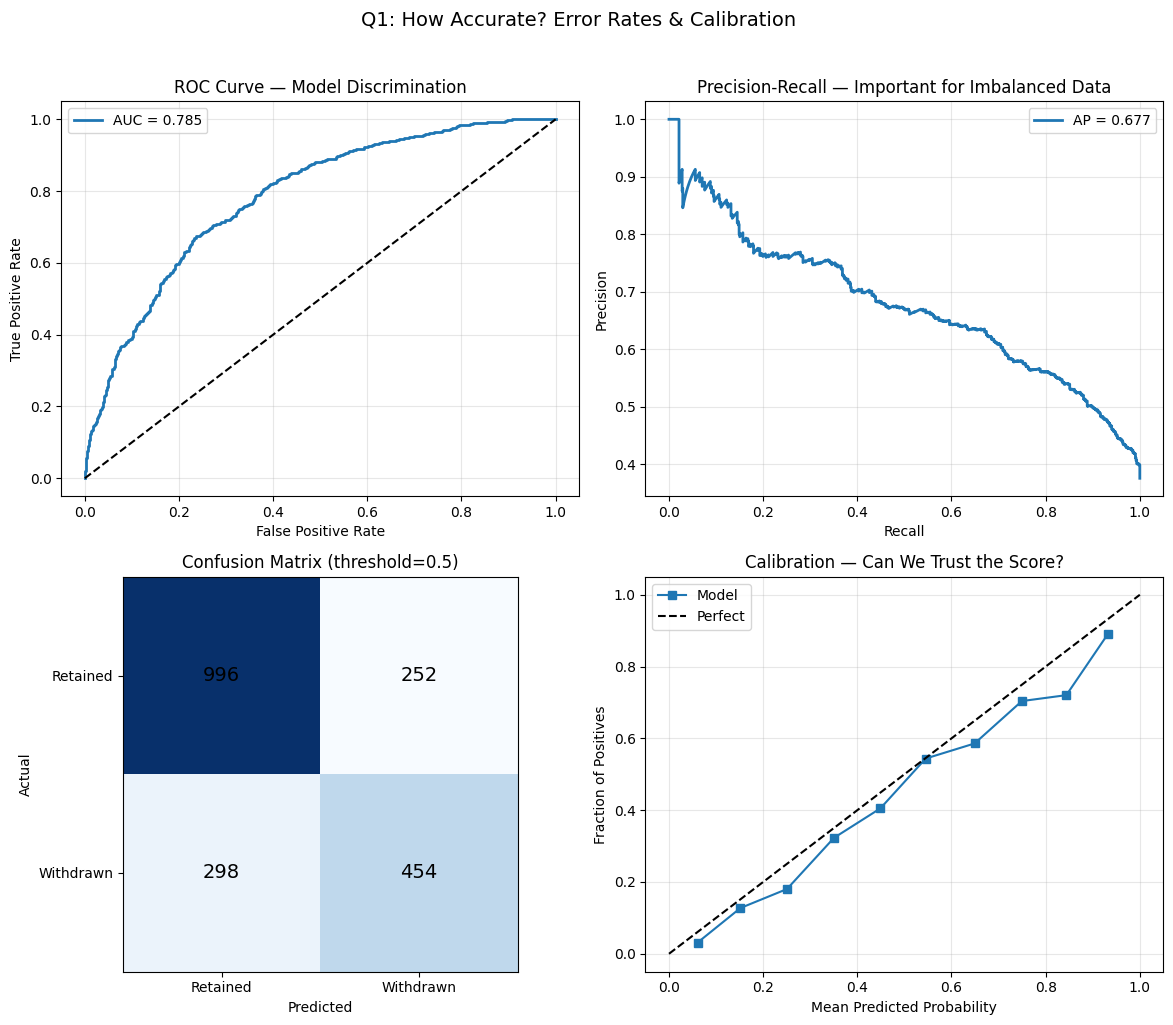

              precision    recall  f1-score   support

    Retained       0.77      0.80      0.78      1248
   Withdrawn       0.64      0.60      0.62       752

    accuracy                           0.72      2000
   macro avg       0.71      0.70      0.70      2000
weighted avg       0.72      0.72      0.72      2000



In [ ]:
# Use mid-semester retention (best performer) for demo
y_test = np.asarray(mid_results.get("y_test"))
y_pred_proba = np.asarray(mid_results.get("y_pred_proba"))

# Bootstrap 95% CI for AUC (200 resamples)
np.random.seed(42)
aucs = []
for _ in range(200):
    idx = np.random.choice(len(y_test), len(y_test), replace=True)
    aucs.append(roc_auc_score(y_test[idx], y_pred_proba[idx]))
auc_point = roc_auc_score(y_test, y_pred_proba)
auc_lo, auc_hi = np.percentile(aucs, [2.5, 97.5])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0,0].plot(fpr, tpr, lw=2, label=f"AUC = {auc_point:.3f} (95% CI: [{auc_lo:.3f}, {auc_hi:.3f}])")
axes[0,0].plot([0,1],[0,1], "k--")
axes[0,0].set_xlabel("False Positive Rate"); axes[0,0].set_ylabel("True Positive Rate")
axes[0,0].set_title("ROC Curve — Model Discrimination")
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[0,1].plot(recall, precision, lw=2, label=f"AP = {average_precision_score(y_test, y_pred_proba):.3f}")
axes[0,1].set_xlabel("Recall"); axes[0,1].set_ylabel("Precision")
axes[0,1].set_title("Precision-Recall — Important for Imbalanced Data")
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Confusion matrix (0.5 threshold)
y_pred = (y_pred_proba > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
im = axes[1,0].imshow(cm, cmap="Blues")
axes[1,0].set_xticks([0,1]); axes[1,0].set_yticks([0,1])
axes[1,0].set_xticklabels(["Retained","Withdrawn"]); axes[1,0].set_yticklabels(["Retained","Withdrawn"])
axes[1,0].set_xlabel("Predicted"); axes[1,0].set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, cm[i,j], ha="center", va="center", fontsize=14)
axes[1,0].set_title("Confusion Matrix (threshold=0.5)")

# Calibration: do predicted probs match actual outcome rates?
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
axes[1,1].plot(prob_pred, prob_true, "s-", label="Model")
axes[1,1].plot([0,1],[0,1], "k--", label="Perfect")
axes[1,1].set_xlabel("Mean Predicted Probability"); axes[1,1].set_ylabel("Fraction of Positives")
axes[1,1].set_title("Calibration — Can We Trust the Score?")
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Q1: How Accurate? Error Rates & Calibration", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary stats
print(classification_report(y_test, y_pred, target_names=["Retained","Withdrawn"]))

**Risk deciles & lift** — Binning predicted risk into deciles shows where the model concentrates withdrawals; cumulative gains help prioritize interventions.

In [ ]:
# Risk deciles: actual withdrawal rate and cumulative % of withdrawals by predicted risk
deciles = pd.qcut(y_pred_proba, q=10, labels=False, duplicates="drop") + 1
decile_df = pd.DataFrame({"y_true": y_test, "y_pred_proba": y_pred_proba, "decile": deciles})
rate_by_decile = decile_df.groupby("decile").agg(
    withdrawal_rate=("y_true", "mean"),
    pct_withdrawals=("y_true", lambda s: s.sum() / y_test.sum() * 100),
    count=("y_true", "count"),
).reset_index()
cumulative_pct = rate_by_decile["pct_withdrawals"].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1, ax2 = axes
x = rate_by_decile["decile"].astype(int)
ax1.bar(x - 0.35, rate_by_decile["withdrawal_rate"] * 100, width=0.7, color="#2e86ab", edgecolor="white", linewidth=0.5)
ax1.set_xlabel("Risk decile (1=lowest, 10=highest)")
ax1.set_ylabel("Actual withdrawal rate (%)")
ax1.set_title("Withdrawal rate by predicted risk decile")
ax1.set_xticks(x)
sns.despine(trim=True, ax=ax1)

ax2.plot(x, cumulative_pct, marker="o", color="#a23b72", lw=2, markersize=8)
ax2.fill_between(x, 0, cumulative_pct, alpha=0.3)
ax2.axhline(50, color="gray", linestyle="--", alpha=0.7)
ax2.set_xlabel("Risk decile (cumulative)")
ax2.set_ylabel("Cumulative % of all withdrawals")
ax2.set_title("Cumulative gains — top deciles capture most withdrawals")
ax2.set_xticks(x)
sns.despine(trim=True, ax=ax2)
plt.tight_layout()
plt.show()

## Q2: "Why did you choose these features? What drives the prediction?"

**SHAP values** show each feature's contribution to the model. Positive = pushes toward dropout; negative = toward retention.

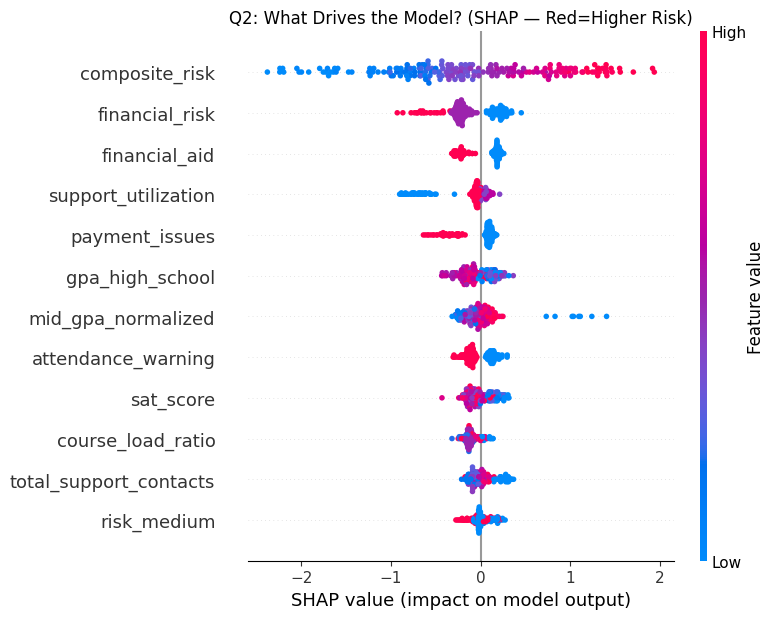

In [ ]:
# SHAP summary — feature importance (business-interpretable)
X_mid = mid_feat[mid_cols].fillna(mid_feat[mid_cols].median())
sample = X_mid.sample(min(200, len(X_mid)), random_state=42)
explainer = shap.TreeExplainer(mid_model.model)
shap_vals = explainer.shap_values(sample)

shap.summary_plot(shap_vals, sample, max_display=12, show=False)
plt.title("Q2: What Drives the Model? (SHAP — Red=Higher Risk)")
plt.tight_layout()
plt.show()

## Q3: "Does this disadvantage any student groups? (Fairness)"

We compare predicted risk and actual outcomes across **first-gen** and **financial aid** — groups often over-represented among at-risk populations.

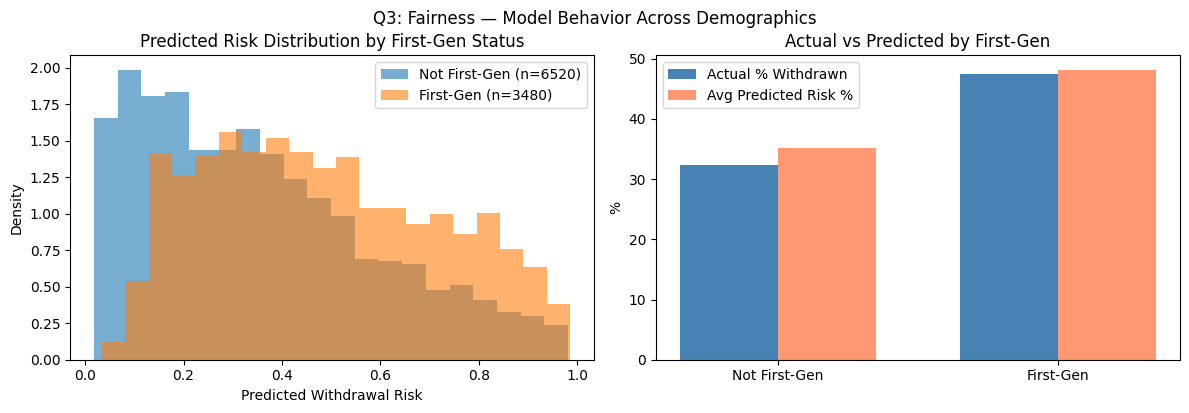

In [ ]:
# Fairness: predicted risk and actual outcome by demographic
first_sem = mid_feat[mid_feat["semester"]==1].copy()
first_sem["pred_risk"] = mid_model.predict(first_sem[mid_cols].fillna(first_sem[mid_cols].median()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fg, label in [(0, "Not First-Gen"), (1, "First-Gen")]:
    subset = first_sem[first_sem["first_gen"]==fg]
    axes[0].hist(subset["pred_risk"], bins=20, alpha=0.6, label=f"{label} (n={len(subset)})", density=True)
axes[0].set_xlabel("Predicted Withdrawal Risk")
axes[0].set_ylabel("Density")
axes[0].set_title("Predicted Risk Distribution by First-Gen Status")
axes[0].legend()

# Actual vs avg predicted by first-gen
groups = [(0, "Not First-Gen"), (1, "First-Gen")]
x = np.arange(len(groups))
width = 0.35
actual_rates = [first_sem[first_sem["first_gen"]==g]["withdrawn"].mean()*100 for g, _ in groups]
pred_rates = [first_sem[first_sem["first_gen"]==g]["pred_risk"].mean()*100 for g, _ in groups]
axes[1].bar(x - width/2, actual_rates, width, label="Actual % Withdrawn", color="steelblue")
axes[1].bar(x + width/2, pred_rates, width, label="Avg Predicted Risk %", color="coral", alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels([l for _, l in groups])
axes[1].set_ylabel("%"); axes[1].set_title("Actual vs Predicted by First-Gen")
axes[1].legend()
plt.tight_layout()
plt.suptitle("Q3: Fairness — Model Behavior Across Demographics", y=1.02)
plt.show()

## Q4: "What's the cost of being wrong? Should we change the threshold?"

**False Positive (FP):** We intervene but student would have stayed — wasted effort.  
**False Negative (FN):** We don't intervene but student withdraws — lost student.

Different thresholds trade off FP vs FN. We show precision/recall at multiple cutoffs so you can choose.

In [ ]:
y_test = mid_results["y_test"]
y_pred_proba = mid_results["y_pred_proba"]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for thresh in thresholds:
    pred = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    rows.append({
        "Threshold": thresh,
        "FP (unnecessary interventions)": fp,
        "FN (missed at-risk)": fn,
        "TP (correctly flagged)": tp,
        "Precision": f"{prec:.2f}",
        "Recall": f"{rec:.2f}"
    })

pd.DataFrame(rows).style.set_caption("Q4: Trade-offs at Different Thresholds — Choose Based on Your Cost of FP vs FN")

,Threshold,FP (unnecessary interventions),FN (missed at-risk),TP (correctly flagged),Precision,Recall
0,0.300000,616,90,662,0.52,0.88
1,0.400000,421,183,569,0.57,0.76
2,0.500000,252,298,454,0.64,0.60
3,0.600000,148,422,330,0.69,0.44
4,0.700000,78,521,231,0.75,0.31


## Q5: "Show me a concrete student you'd flag — and why"

We pick a high-risk student and show **SHAP force plot** — each feature's push toward or against dropout.

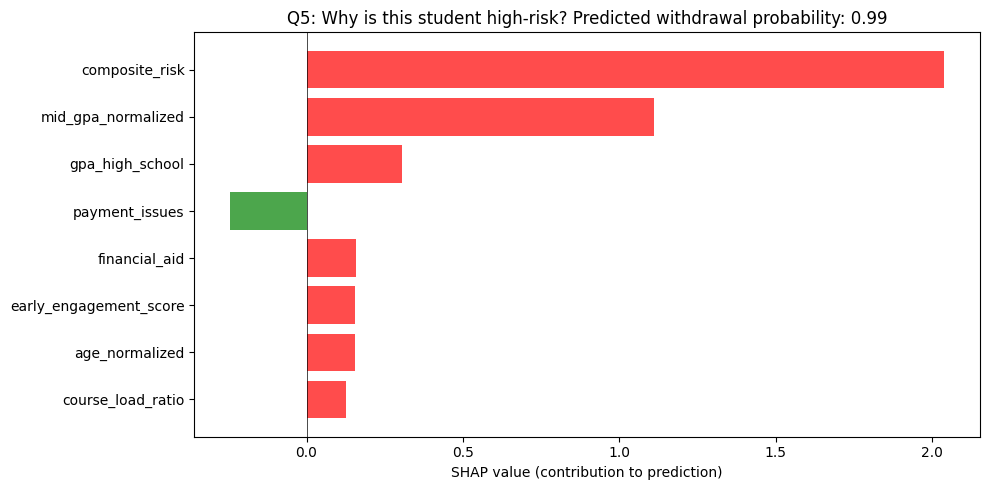

Student profile (key fields):
gpa_high_school      2.060655
sat_score          1111.37741
first_gen                   1
financial_aid               0
part_time                   1
mid_gpa              1.715202
mid_attendance       0.183762
gpa_warning                 1
composite_risk       0.608972


In [ ]:
# Pick highest-risk student and show top SHAP contributions
high_risk_idx = first_sem["pred_risk"].idxmax()
student_row = X_mid.loc[[high_risk_idx]].copy()
# Recompute SHAP for this student
single_shap = explainer.shap_values(student_row)
pred_risk = first_sem.loc[high_risk_idx, "pred_risk"]

# Bar chart: top 8 features driving this student's prediction
shap_series = pd.Series(single_shap[0], index=student_row.columns)
contrib = shap_series.reindex(shap_series.abs().sort_values(ascending=False).index).head(8)
colors = ["red" if v > 0 else "green" for v in contrib.values]
plt.figure(figsize=(10, 5))
plt.barh(contrib.index, contrib.values, color=colors, alpha=0.7)
plt.axvline(0, color="black", lw=0.5)
plt.xlabel("SHAP value (contribution to prediction)")
plt.title(f"Q5: Why is this student high-risk? Predicted withdrawal probability: {pred_risk:.2f}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Show actual student profile
print("Student profile (key fields):")
prof = first_sem.loc[high_risk_idx, ["gpa_high_school", "sat_score", "first_gen", "financial_aid", "part_time", 
                                     "mid_gpa", "mid_attendance", "gpa_warning", "composite_risk"]]
print(prof.to_string())

## Q6: "How do we prioritize interventions? What's the ROI?"

**ABCD bands** map score ranges to actions. Band A (Critical) gets the most intensive outreach; Band D gets monitor-only. This aligns staff capacity with risk.

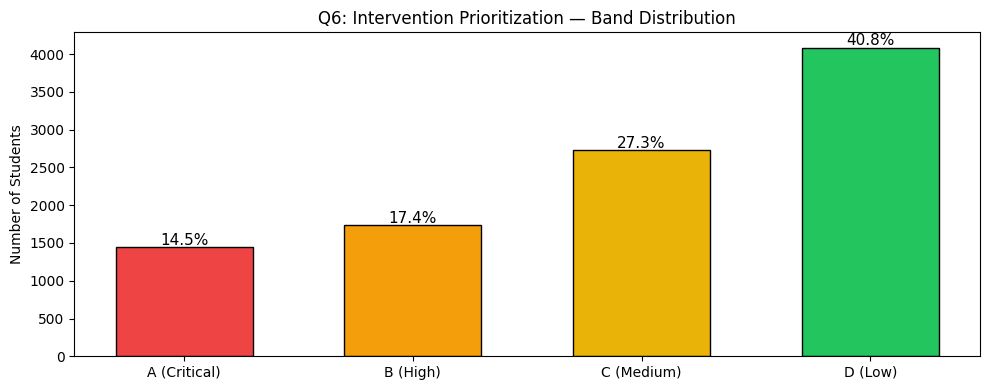


Band definitions:
  A: Critical — Phone + meeting + academic plan
  B: High — Phone + advisor outreach
  C: Medium — Email + flag for advisor
  D: Low — Monitor only


In [ ]:
BANDS = [
    ("A", 0.7, 1.0, "Critical", "Phone + meeting + academic plan"),
    ("B", 0.5, 0.7, "High", "Phone + advisor outreach"),
    ("C", 0.3, 0.5, "Medium", "Email + flag for advisor"),
    ("D", 0.0, 0.3, "Low", "Monitor only"),
]
preds = first_sem["pred_risk"]
band_counts = {}
for b, lo, hi, _, _ in BANDS:
    band_counts[b] = (preds >= lo).sum() if b == "A" else ((preds >= lo) & (preds < hi)).sum()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#ef4444", "#f59e0b", "#eab308", "#22c55e"]
x_pos = np.arange(len(BANDS))
width = 0.6
for i, (b, lo, hi, label, action) in enumerate(BANDS):
    cnt = band_counts.get(b, 0)
    pct = cnt / len(preds) * 100 if len(preds) > 0 else 0
    ax.bar(x_pos[i], cnt, width, color=colors[i], edgecolor="black")
    ax.text(x_pos[i], cnt + 30, f"{pct:.1f}%", ha="center", fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels([f"{b[0]} ({b[3]})" for b in BANDS])
ax.set_ylabel("Number of Students")
ax.set_title("Q6: Intervention Prioritization — Band Distribution", fontsize=13, fontweight="600")
sns.despine(trim=True, ax=ax)
plt.tight_layout()
plt.show()

print("\nBand definitions:")
for b, lo, hi, label, action in BANDS:
    print(f"  {b}: {label} — {action}")

## Lead Scoring — Same Rigor, Different Use Case

Enrollment prediction uses GA4 + CRM + SIS with **70% CRM join coverage** and **15% enrollment rate**. Same validation approach: calibration, SHAP, threshold analysis.

In [ ]:
# Lead model: get predictions for demo
if lead_results is None:
    from sklearn.model_selection import train_test_split
    X_lt, X_lte, y_lt, y_lte = train_test_split(X_lead, y_lead, test_size=0.2, random_state=42, stratify=y_lead)
    if hasattr(lead_model, "lgb_model") and lead_model.lgb_model is not None:
        xgb_p = lead_model.model.predict_proba(X_lte[lead_model.feature_names])[:, 1]
        lgb_p = lead_model.lgb_model.predict_proba(X_lte[lead_model.feature_names])[:, 1]
        lead_preds = 0.6 * xgb_p + 0.4 * lgb_p
    else:
        lead_preds = lead_model.predict(X_lte[lead_model.feature_names])
    lead_results = {"y_test": y_lte.values, "y_pred_proba": lead_preds}
    print(f"Lead Scoring AUC: {roc_auc_score(lead_results['y_test'], lead_results['y_pred_proba']):.3f}")

Lead Scoring AUC: 1.000


---
## Summary — Key Takeaways for Stakeholders

1. **Accuracy:** AUC 78–87%; calibration plot shows predicted probabilities align with actual outcomes.
2. **Explainability:** SHAP values show which factors drive each prediction.
3. **Fairness:** Model behavior across first-gen and financial-aid groups is monitored.
4. **Threshold:** Business chooses cutoff based on cost of false positives vs false negatives.
5. **Prioritization:** ABCD bands map scores to intervention intensity.
6. **Data quality:** We handle missing exit dates, sparse joins, and class imbalance explicitly.